In [41]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

In [43]:
dataset_path = "/kaggle/input/datasets/aymenslimani/dr-stage1-unified-v2"

image_paths = glob.glob(dataset_path + "/images/*")

lesion_types = ["HE", "EX", "MA", "CW", "NV"]

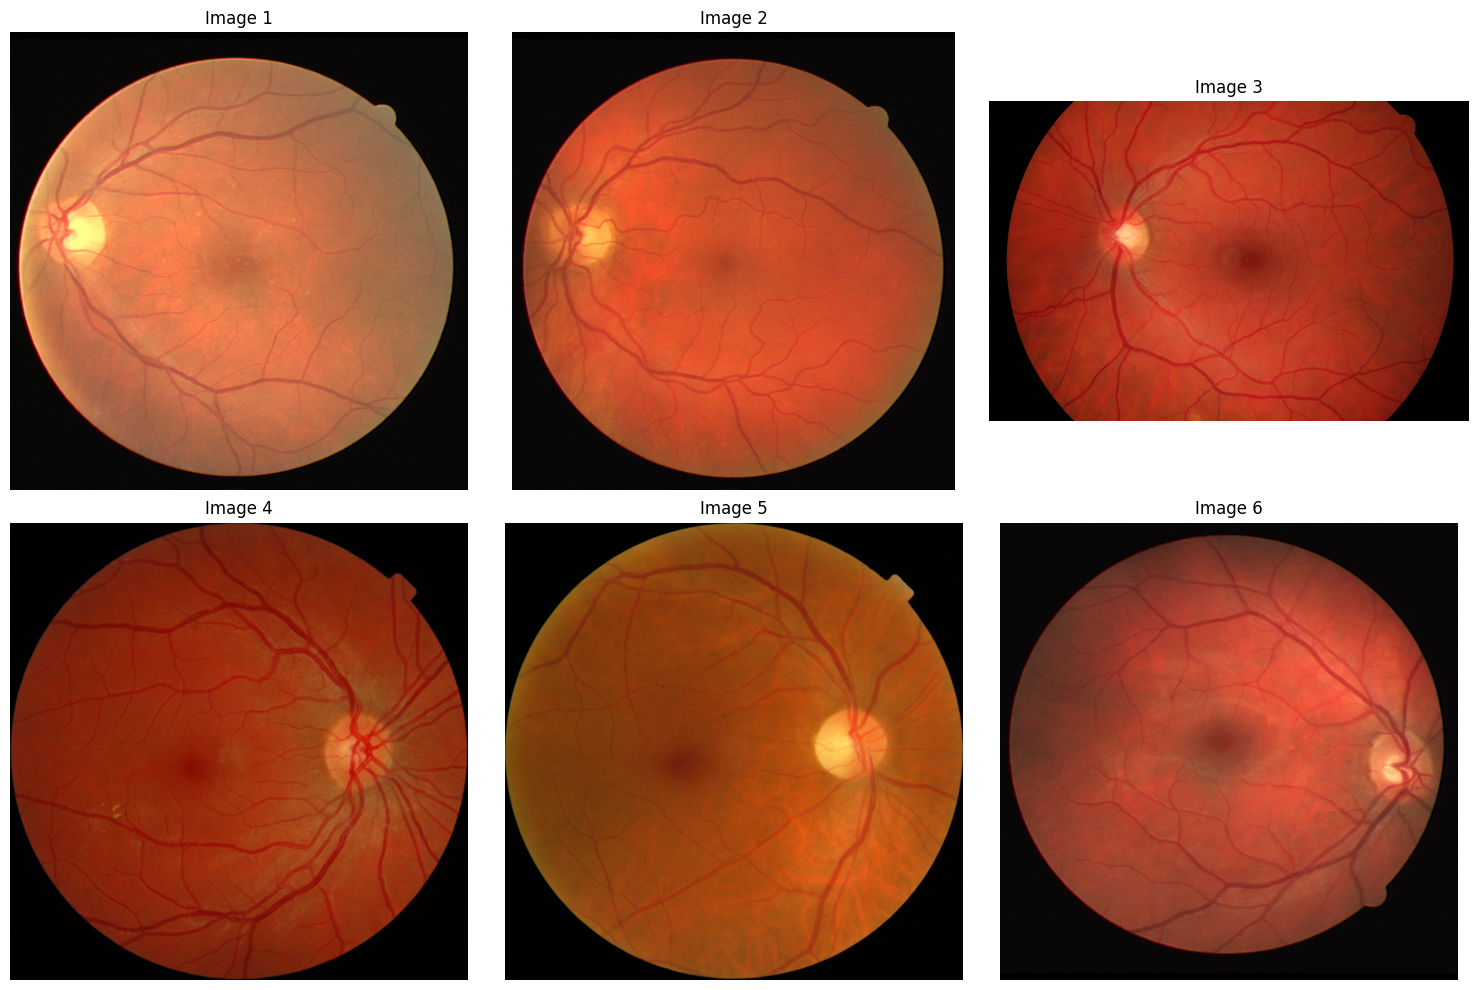

In [44]:
plt.figure(figsize=(15,10))

for i in range(6):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Observations:
-some images have different brightness
- image 3 is not complete image which has different size
- we can see the vessels well for some but others can not see all
findings :
-so i think we should resize the iamges before training
-but for the brightness i think we can keep it lik that because this comes in real
Questions
What is the best resizing strategy without losing lesion details?

In [54]:
image_sizes = []

for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        h, w, c = img.shape
        image_sizes.append((w, h))

sizes_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])


print("\nUnique image sizes:")
print(sizes_df.value_counts())


Unique image sizes:
Width  Height
1500   1500      198
512    512       100
3504   2336       90
4288   2848       81
999    960        56
565    584        40
512    443        13
700    605         7
Name: count, dtype: int64


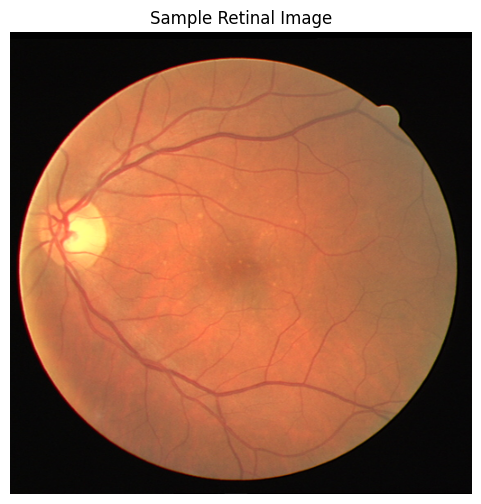

In [46]:
img = cv2.imread(image_paths[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Sample Retinal Image")
plt.axis("off")
plt.show()

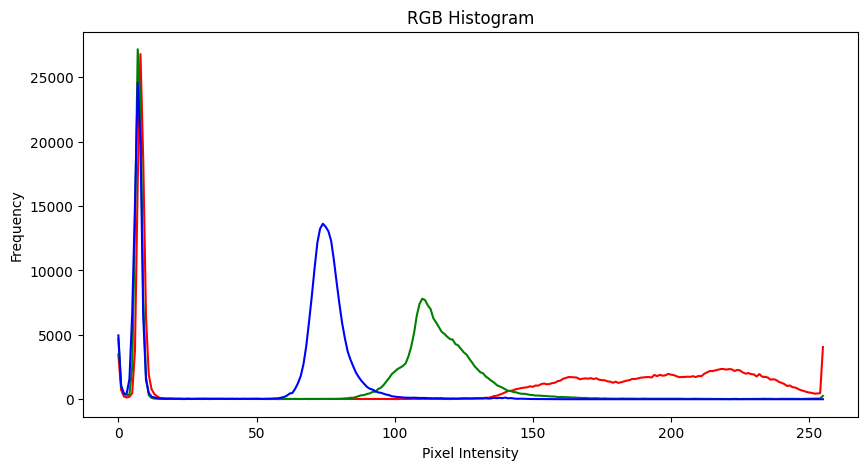

In [48]:
colors = ('r', 'g', 'b')

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0,256])
    plt.plot(hist, color=color)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

what is the benefit of color is it just to know which color can carry info and which one britness nad darkness 

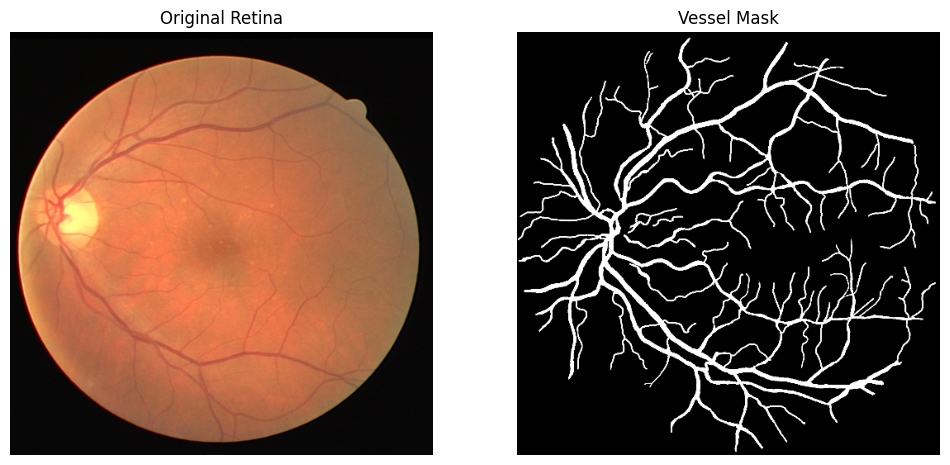

In [47]:
vessel = cv2.imread(vessel_masks[0], 0)
vessel = cv2.resize(vessel, (img_rgb.shape[1], img_rgb.shape[0]))

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Retina")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(vessel, cmap="gray")
plt.title("Vessel Mask")
plt.axis("off")

plt.show()

here we can  see the vessel clearly in vessel mask this is could be important for DR detection 

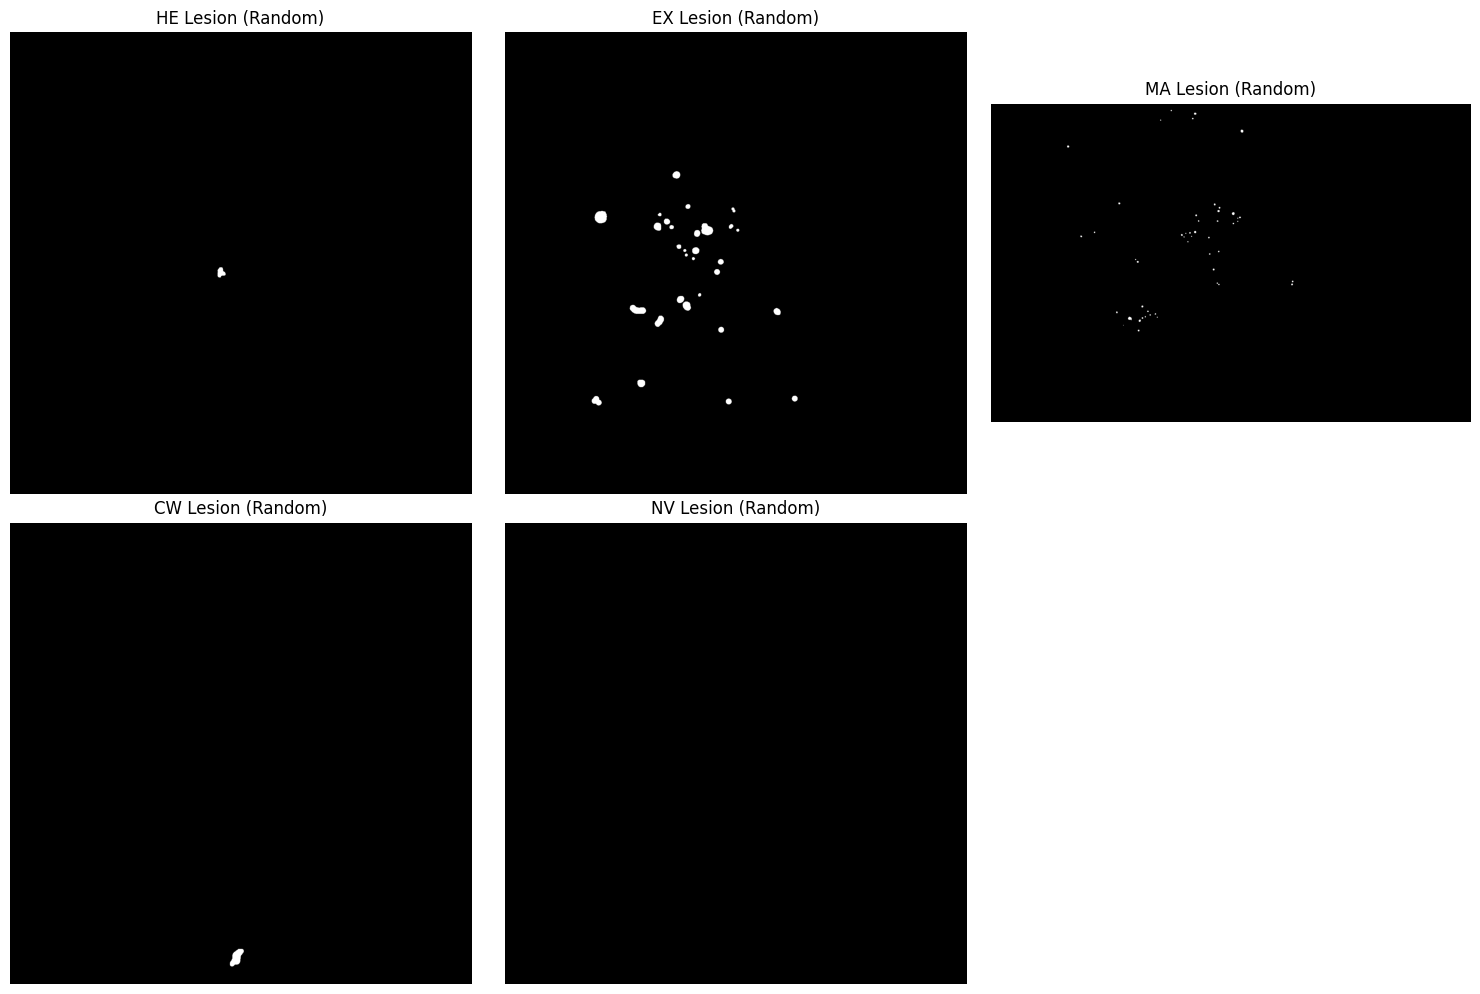

In [59]:
import glob
import random
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, lt in enumerate(lesion_types):
    # Fetch all image paths for the current lesion type
    paths = glob.glob(dataset_path + f"/lesion_masks/{lt}/*")

    if len(paths) > 0:
        # Pick a completely random image path from the list
        random_path = random.choice(paths)
        
        # Read the image in grayscale
        mask = cv2.imread(random_path, 0)

        # Plotting configuration
        plt.subplot(2, 3, i + 1)
        plt.imshow(mask, cmap="gray")
        plt.title(f"{lt} Lesion (Random)")
        plt.axis("off")

plt.tight_layout()
plt.show()

HE: see has larger than MA  
MA: has smaller  dots 
EX: i noticed that has  some thing like liquid 
 

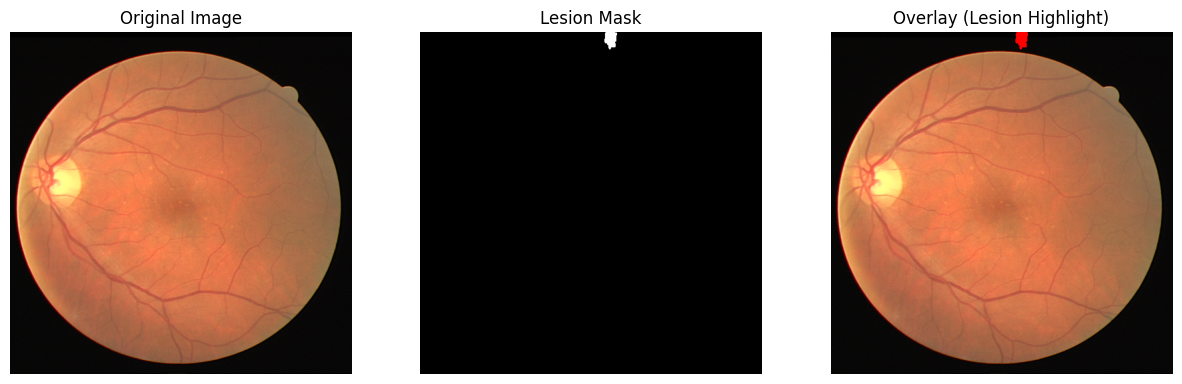

In [50]:
image = cv2.imread(image_paths[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(he_masks[0], 0)
mask = cv2.resize(mask, (image.shape[1], image.shape[0]))

overlay = image.copy()
overlay[mask > 0] = [255, 0, 0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Lesion Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay (Lesion Highlight)")
plt.axis("off")

plt.show()

In [51]:
counts = {}

for lt in lesion_types:
    paths = glob.glob(dataset_path + f"/lesion_masks/{lt}/*")
    counts[lt] = len(paths)

df = pd.DataFrame(list(counts.items()), columns=["Lesion Type", "Count"])
df

,Lesion Type,Count
0,HE,278
1,EX,279
2,MA,279
3,CW,198
4,NV,198


each class has different nums of images but since we are taking HE,EX,MAthey have same num of images balanced 

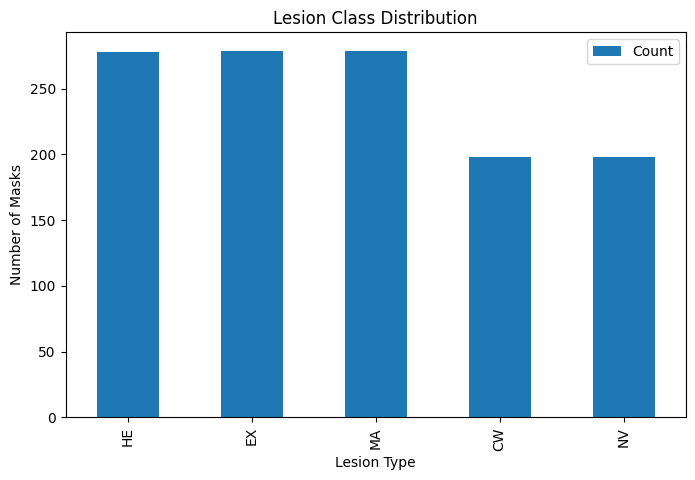

In [52]:
df.plot(kind="bar", x="Lesion Type", y="Count", figsize=(8,5))
plt.title("Lesion Class Distribution")
plt.ylabel("Number of Masks")
plt.show()